In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

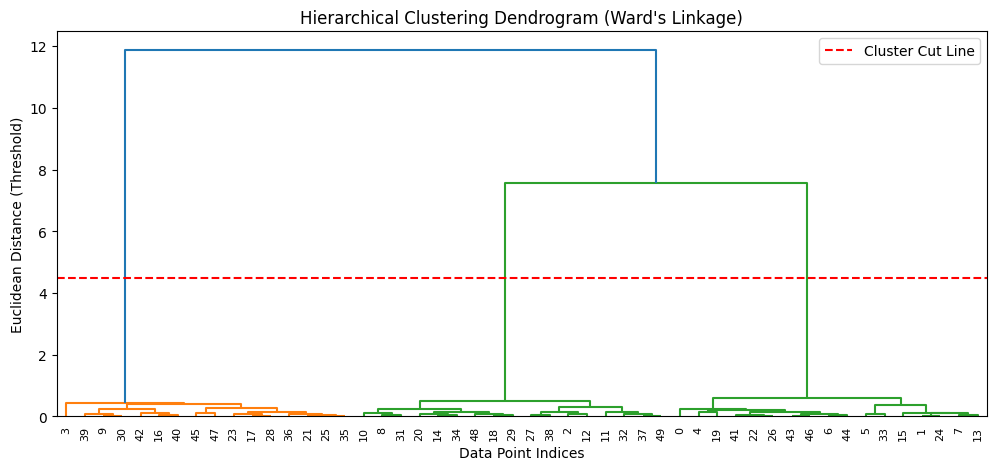

=== Hierarchical Clustering Output ===
First 10 Assigned Cluster Labels: [0 0 2 1 0 0 0 0 2 1]


In [1]:
#Topic 133 | Introduction to Hierarchical Clustering
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# 1. Dataset generate karein (Naturally 3 groups)
X, _ = make_blobs(n_samples=50, centers=3, cluster_std=0.60, random_state=42)

# Distance-based algorithm hai, isliye scaling zaroori hai
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------------
# STEP 2: SciPy ka use karte hue Dendrogram Plot Karein
# ------------------------------------------------------------------
# Hum Ward's linkage method use kar rahe hain matrix generate karne ke liye
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward's Linkage)")
plt.xlabel("Data Point Indices")
plt.ylabel("Euclidean Distance (Threshold)")
plt.axhline(y=4.5, color="r", linestyle="--", label="Cluster Cut Line")
plt.legend()
plt.show()

# ------------------------------------------------------------------
# STEP 3: Scikit-Learn ke sath Final Cluster Labels Assign Karein
# ------------------------------------------------------------------
# Dendrogram dekh kar agar hum threshold set karein, toh humein 3 clusters milte hain
agg_cluster = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
labels = agg_cluster.fit_predict(X_scaled)

print("=== Hierarchical Clustering Output ===")
print(f"First 10 Assigned Cluster Labels: {labels[:10]}")